In [1]:
# import libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3

In [2]:
# import database / connect to database

connection = sqlite3.connect('D:\\Power BI Project\\Portfolio_Project\\Data\\customer_churn.db')

# execute SQL query to get the all list of tables in the database
sql_query = """
    SELECT name 
    FROM sqlite_master
    WHERE type='table';
"""

tables_df = pd.read_sql(sql_query, connection)

# create a DataFrame for each table in the database
for table_name in tables_df['name']:
    df = pd.read_sql(f'SELECT * FROM {table_name}', connection)
    globals()[f'df_{table_name}'] = df # store the DataFrame in a variable with the same name as the table
    print(f"Created Dataframe: df_{table_name}")


connection.close()

Created Dataframe: df_db_customer
Created Dataframe: df_db_subscription
Created Dataframe: df_db_support


In [3]:
# Print table names and column names

conn = sqlite3.connect('D:\\Power BI Project\\Portfolio_Project\\Data\\customer_churn.db')

for table_name in tables_df['name']:
    print(f"\nTable: {table_name}")

    # Get column information for the current table
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")

    print(columns['name'].tolist()) # print the column names as a list

# close the connection
conn.close()


Table: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


### *Data Cleaning and Preprocessing :-*

### *1. Table*

In [4]:
# df_db_customer.head()
df_db_customer.tail(10)

,customerid,name,country,state,gender,dob,interests,pincode
11,0017-IUDMW,rangadevi,India,Karnataka,Female,1981-06-18 00:00:00,None,None
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01 00:00:00,None,None
13,0019-EFAEP,raju,India,Meghalaya,Female,1992-04-25 00:00:00,None,None
14,0019-GFNTW,Madhav,India,Uttar Pradesh,Men,1979-11-11 00:00:00,None,None
15,0020-INWCK,parvati,India,Delhi,Female,1986-02-28 00:00:00,job,None
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [5]:
# Checking missing value

df_db_customer.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [6]:
# a. rename cols - name to customer_name
# b. drop cols - interest and pincode 
# c. change data type - dob 
# d. Data standardization - gender
# e. fix missing value - country

In [7]:
# a. rename cols - name to customer_name

df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)

df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [8]:
# b. drop cols - interest and pincode 

# one way with index wise - sightly hard  /  axis=(row=0 - cols=1)
# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)


# Second way with columns name direct - bit easy
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [9]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [10]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [11]:
# c. change data type - dob 

df_db_customer['dob']  = pd.to_datetime(df_db_customer['dob'])

In [12]:
# d. Data standardization - gender

# df_db_customer['gender'].unique()

df_db_customer.replace({'Men':'Male', 'Women':'Female'}, inplace=True)

In [13]:
# e. fix missing value - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [14]:
# country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [15]:
# same as inplace :-

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

### *2. Table*

In [16]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [17]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [18]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

### *3. Table*

In [19]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [20]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [21]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [22]:
df_db_support['complaint_date'] = df_db_support['complaint_date'].apply(pd.to_datetime)

### *Feature Engineering and Data Analysis :-*

In [23]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [24]:
# create a new col using existing col  - churn_Flag

df_db_subscription['churn_Flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [25]:
# first fix support table duplicate rows then merge

df = (df_db_subscription
                .merge(df_db_customer, on= 'customerid', how='left') 
                .merge(df_db_support, on= 'customerid', how='left') )

In [26]:
df_db_subscription.shape

(21, 12)

In [27]:
 # two rows extra duplicated
df.shape

(23, 20)

In [28]:
# Checking unique customerid

df_db_subscription['customerid'].nunique()

21

In [29]:
df_db_customer['customerid'].nunique()

21

In [30]:
df_db_support['customerid'].nunique()

7

In [31]:
# duplicate rows

df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [32]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [33]:
df_db_support = df_db_support.sort_values(by='complaint_date').drop_duplicates('customerid', keep='last')

In [34]:
# merge df

df = (df_db_subscription
                .merge(df_db_customer, on= 'customerid', how='left') 
                .merge(df_db_support, on= 'customerid', how='left') )

In [35]:
df.shape

(21, 21)

In [36]:
# exported the data file for analysis :

df.to_csv('D:\\Power BI Project\\Portfolio_Project\\exported_churn_data.csv', index=False)

## *Data Analysis :-*

In [37]:
# 1. Churn Rate 

churn_rate = df['churn_Flag'].mean()*100
print(f"Churn rate: {round(churn_rate, 2)}%")

Churn rate: 28.57%


In [38]:
# 2. Retention Rate 

retention_rate = 100 - churn_rate
print(f"Retention Rate: {round(retention_rate, 2)}%")

Retention Rate: 71.43%


In [39]:
# 3. churn by Plan Type 

churn_by_plan_type = (df.groupby('plan_type')['churn_Flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print(churn_by_plan_type) # maximum generate by Basic 

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [40]:
# ARPU - Avg revenue per users

arpu = df['monthly_charges'].mean().round(2)

print(f"ARPU: {arpu}")

ARPU: 18.85


In [41]:
# Avg Customer Tenure
# Count of days users has used our service : cancellation date else current date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(), (df['cancellation_date'] - df['subscription_start_date']).dt.days, 
        (today - df['subscription_start_date']).dt.days
) 

avg_tenure = df['tenure_days'].mean() 

print(f"Avg Tenure (Days): {round(avg_tenure)}")

Avg Tenure (Days): 1551


In [42]:
# Revenue at risk - revenue lost from churned users

revenue_at_risk = df.loc[df['churn_Flag'] == 1, 'monthly_charges'].sum()
print(f"Revenue at risk (Rs 'K'): {revenue_at_risk}")

Revenue at risk (Rs 'K'): 73.94


In [43]:
# Escalation Rate 

escalations_rate = (df['escalations'] == 'Y').mean()*100

print(f"Escalations Rate : {round(escalations_rate, 2)} %")

Escalations Rate : 19.05 %


In [44]:
# Avg complaint Per user

avg_complaint_user = df['complaint_count'].sum() / df['customerid'].nunique()

print(f"Avg Complaint Per user: {round(avg_complaint_user, 2)}")

Avg Complaint Per user: 0.43


In [45]:
# Correlation Escalation vs Churn

df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type 

corr_df = df[['escalations', 'churn_Flag']].dropna()


correlation = corr_df['escalations'].corr(df['churn_Flag'])

print(f"Correlation B/W  escalation vs churn : {round(correlation, 2)}")

Correlation B/W  escalation vs churn : 0.77


In [46]:
# Create a column using existing col - Churn risk 

conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'mid', 'high']

df['churn_risk'] = np.select(conditions, choices, default='Unknown')

In [47]:
df[['churn_risk', 'churn_score']].tail()

,churn_risk,churn_score
16,mid,62
17,low,27
18,high,99
19,low,7
20,low,47


###  *Data Visualization :-*

In [48]:
# Create a copy of dataframe for safety

df_visual = df.copy()

In [49]:
# Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

In [50]:
churn_trend = df_visual[df_visual['churn_Flag'] == 1].groupby('cancellation_month').size()

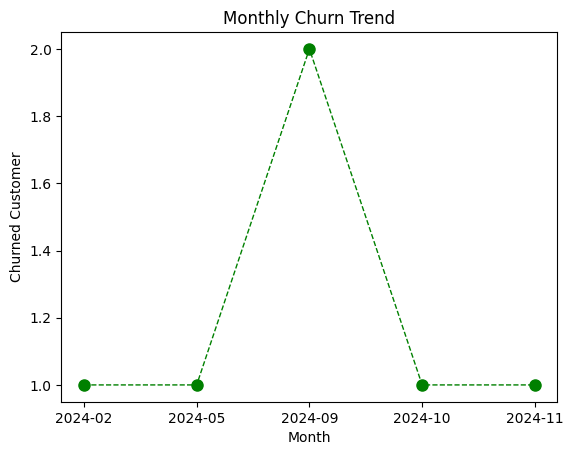

In [51]:
plt.Figure(figsize=(8, 3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=1, markersize=8)


plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customer')
plt.show() 

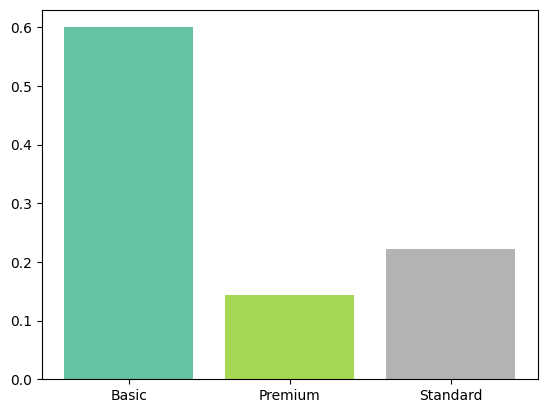

In [52]:
# churn By Plan type 

churn_plan = df_visual.groupby('plan_type')['churn_Flag'].mean()


# color set [Manual]
color = ['yellow', 'purple', 'blue']

# Dynamic Color [randomly]
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.Figure(figsize=(8, 3))
plt.bar(churn_plan.index, churn_plan.values, color= colors)
plt.show()

<BarContainer object of 9 artists>

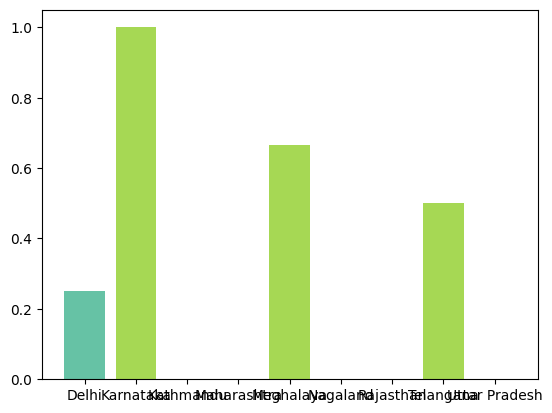

In [53]:
# Churn by State 

churn_state = df_visual.groupby('state')['churn_Flag'].mean()

# Dynamic Color [randomly]
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.Figure(figsize=(12, 10))
plt.bar(churn_state.index, churn_state.values, color= colors)

In [54]:
# Visualization using Seaborn :-

In [55]:
# encoding - convert str to numeric so that we can find corr between feature 


# incorrect method of encoding - as number are not assigned based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_Flag', 'churn_risk', 'escalations']].head()


categorial_cols = ['plan_type', 'contract_type', 'churn_risk']


for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [56]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_Flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

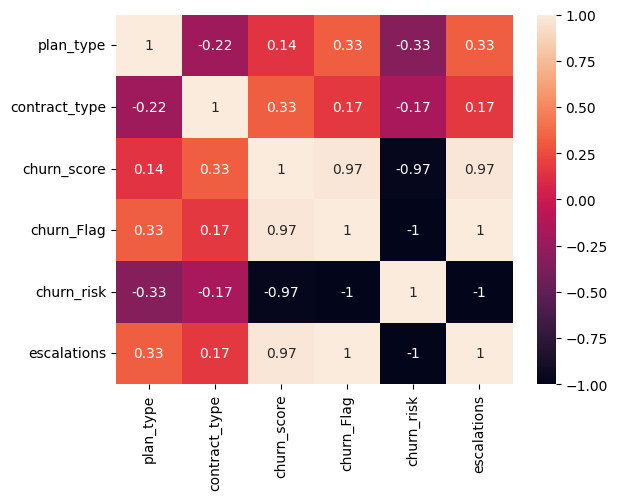

In [57]:
# Heatmap (correlation matrix)


sns.heatmap(df_encoded.corr(), annot=True)

In [58]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'mid'], dtype=object)

In [59]:
# Correct method of encoding - based on Priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_Flag', 'churn_risk', 'escalations']].head()


order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk' : ['low', 'mid', 'high']
}


for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [60]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_Flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

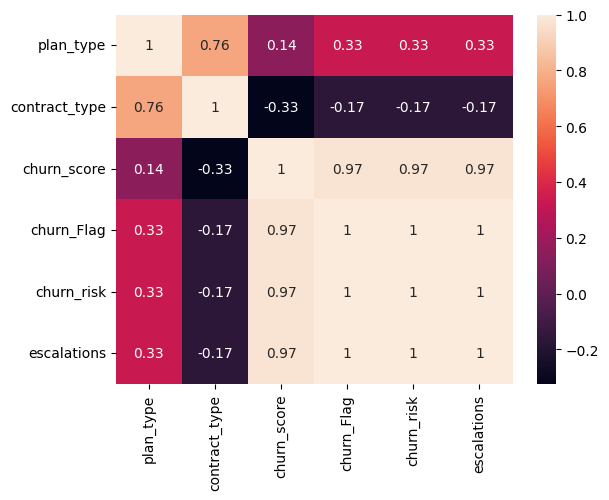

In [61]:
# Heatmap (correlation matrix) - Corrected

sns.heatmap(df_encoded.corr(), annot=True)

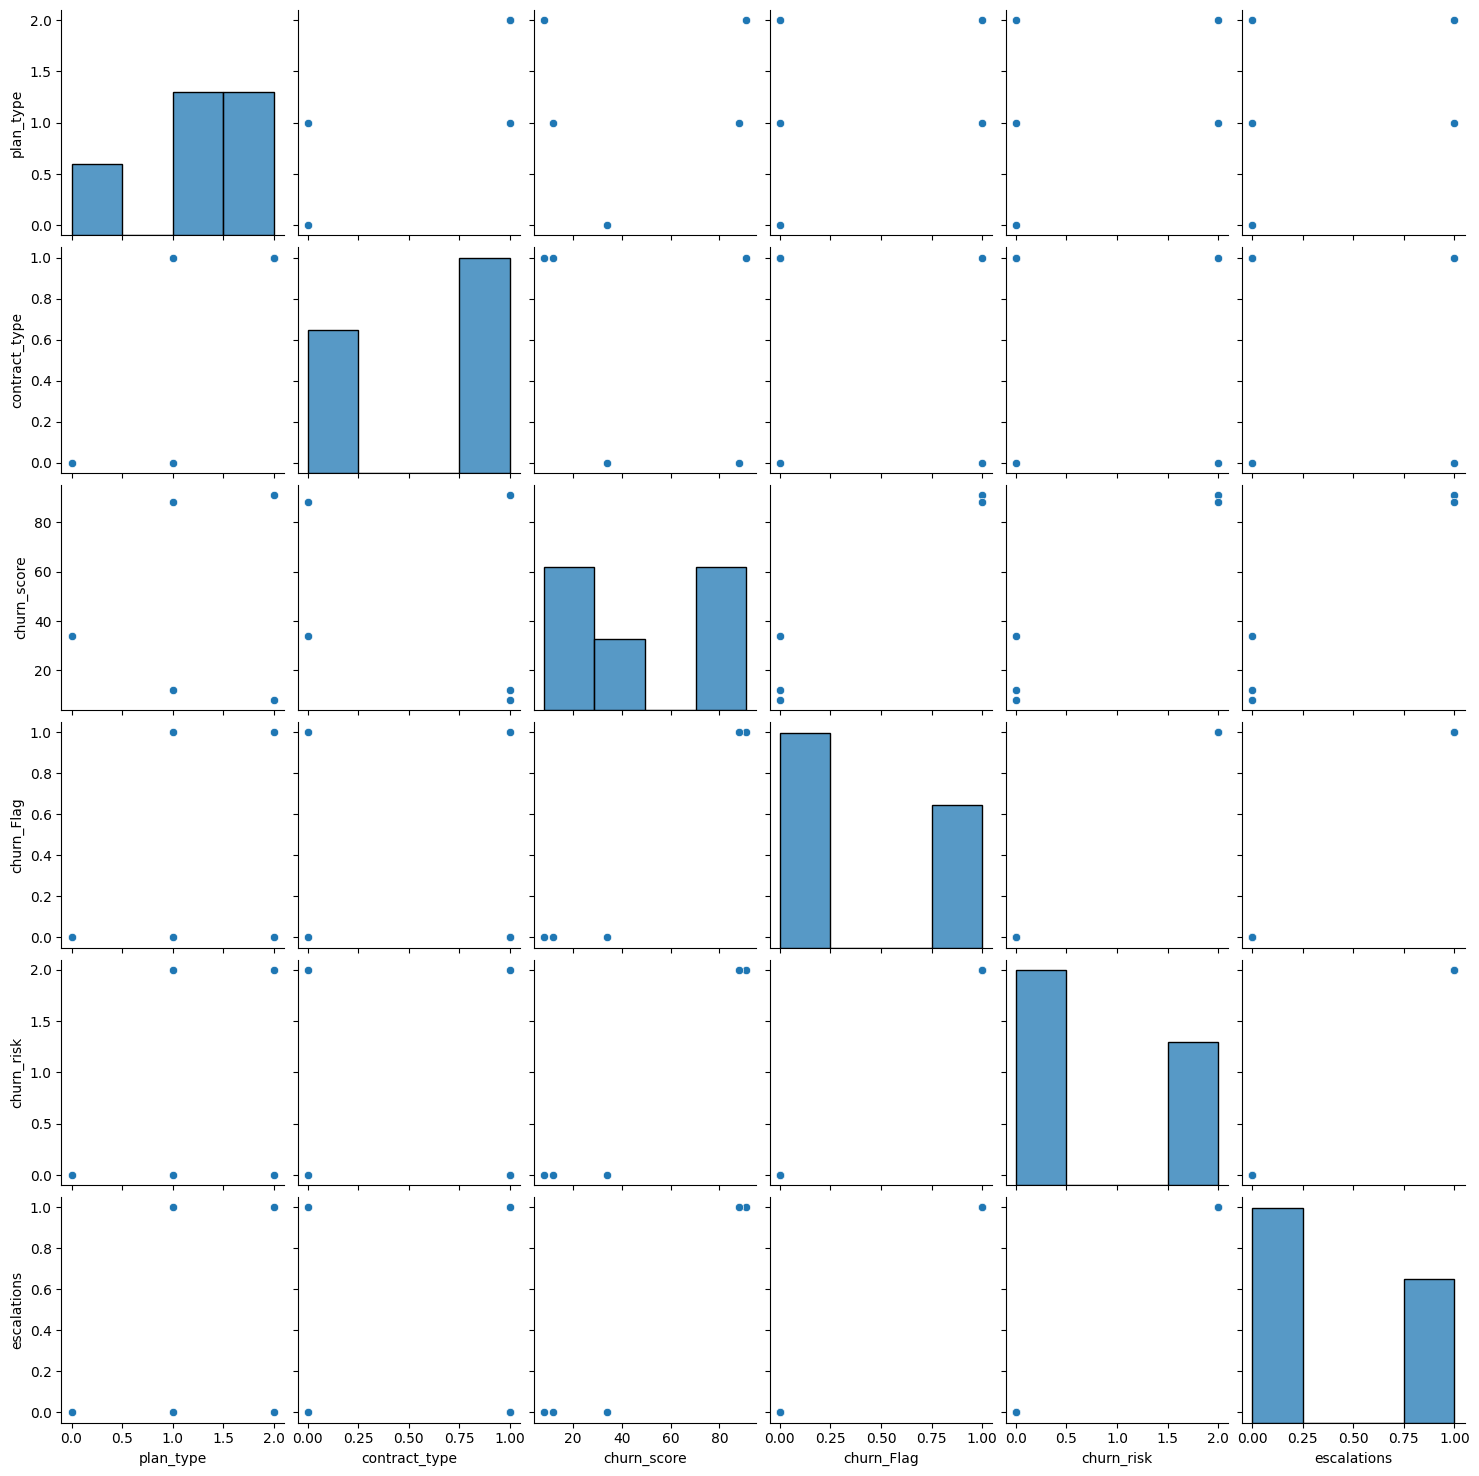

In [62]:
##  Pair Plot - relationship in dataset


sns.pairplot(df_encoded)

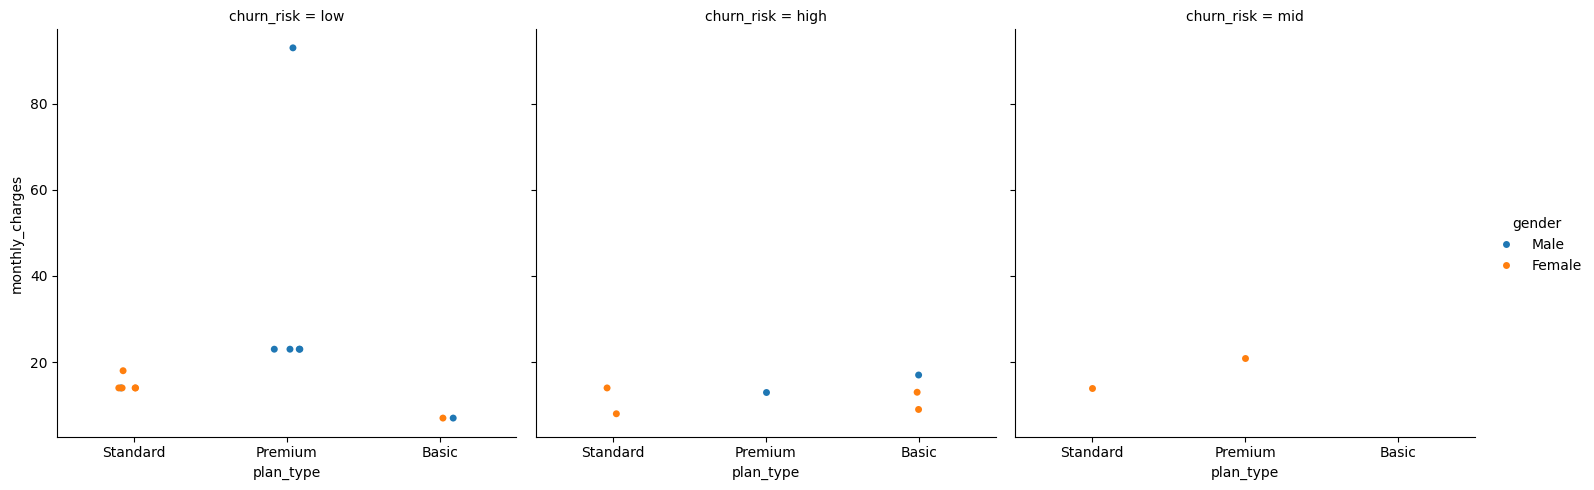

In [63]:
## catplt / Facegrid plot - multi- dimensional comparison 


sns.catplot(data=df_visual, x='plan_type', y='monthly_charges', hue='gender', col='churn_risk')

In [64]:
## Pivot Table :- 

In [ ]:
# Basic Lvl

pd.pivot_table(df_visual, values='churn_Flag', index='plan_type', aggfunc='mean')

,churn_Flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [67]:
pd.pivot_table(df_visual, index='plan_type', values=['monthly_charges', 'customerid', 'churn_Flag'], 
    aggfunc= {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_Flag' : 'mean'
    }
)

,churn_Flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
